In [1]:

import sys
sys.path.insert(0, '../src')
# Import packages
import pandas as pd
import numpy as np
import matplotlib
from matplotlib import dates as mdates
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from pmdarima import auto_arima
import pmdarima as pm
from scipy.stats import boxcox
from scipy.special import inv_boxcox

from sklearn.metrics import root_mean_squared_error, mean_absolute_percentage_error, mean_squared_error
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf



In [2]:
from Baselines import NaiveSeasonalWithDrift, TripleExponentialSmoothing
from preprocessing import load_data, retrieve_airport_data
from functions import evaluate_forecast, make_rolling_splits, make_rolling_splits_weekly


In [3]:
#Import and process weekly data for Chicago airport
data = load_data("../data/tsa-throughput-data-complete.csv")
data_ord_w = retrieve_airport_data(data, "ORD", frequency="W")


In [4]:
data_ord_w.head()

,datetime,total_passenger_throughput,week
0,2022-01-09,351922,1
1,2022-01-16,311935,2
2,2022-01-23,298777,3
3,2022-01-30,289786,4
4,2022-02-06,302673,5


In [5]:
data_ord_w.iloc[181]
data_ord_w_train= data_ord_w[data_ord_w.index <= 103]
data_ord_w_train.tail()

,datetime,total_passenger_throughput,week
99,2023-12-03,499512,48
100,2023-12-10,485039,49
101,2023-12-17,490981,50
102,2023-12-24,538606,51
103,2023-12-31,567014,52


In [6]:
#Let's visualize the weekly throughput data for Chicago O'Hare
px.line(data_ord_w, x='datetime', y='total_passenger_throughput', 
        labels={'total_passenger_throughput': 'Weekly Throughput'},
        template="simple_white", 
        title='Weekly Throughput at ORD',
        height=500, width=1000).update_layout(font=dict(size=14), title_x=0.5).show()

We want to run STL decomposition on this data. We will make time-series splits for cross-validation. We keep the data after June 29, 2025 untouched for testing.

In [7]:
data_ord_w_train= data_ord_w[data_ord_w.index <= 181]
splits = make_rolling_splits_weekly(data_ord_w_train, date_col='datetime', n_splits=5, step_weeks=13)

Split 1: train → row 116 (2024-03-31) | test rows 117–129 (2024-04-07 → 2024-06-30) (13 weeks)
Split 2: train → row 129 (2024-06-30) | test rows 130–142 (2024-07-07 → 2024-09-29) (13 weeks)
Split 3: train → row 142 (2024-09-29) | test rows 143–155 (2024-10-06 → 2024-12-29) (13 weeks)
Split 4: train → row 155 (2024-12-29) | test rows 156–168 (2025-01-05 → 2025-03-30) (13 weeks)
Split 5: train → row 168 (2025-03-30) | test rows 169–181 (2025-04-06 → 2025-06-29) (13 weeks)


Expectedly there's yearly (and weekly) seasonality in the data. Before running STL + SARIMA in cross-validated splits, for simplicity let's see how it works on the entire training set.

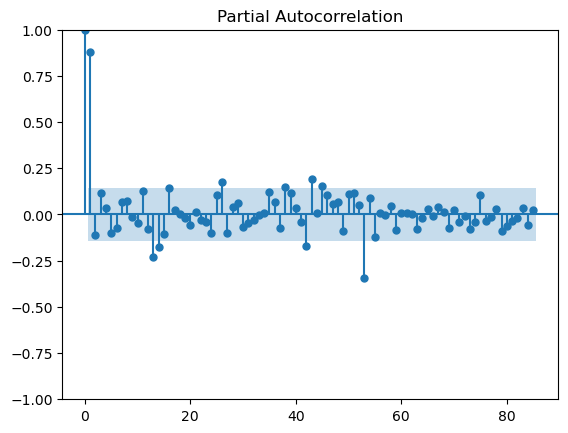

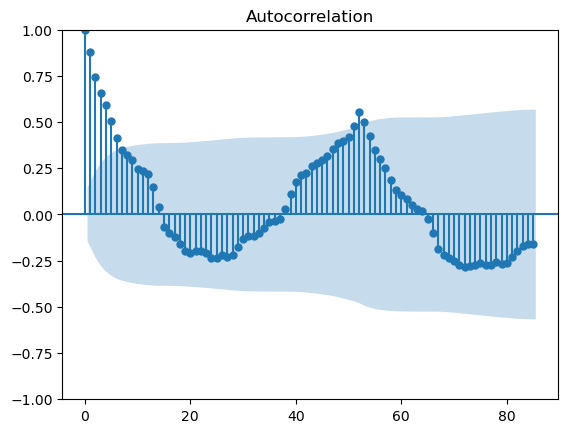

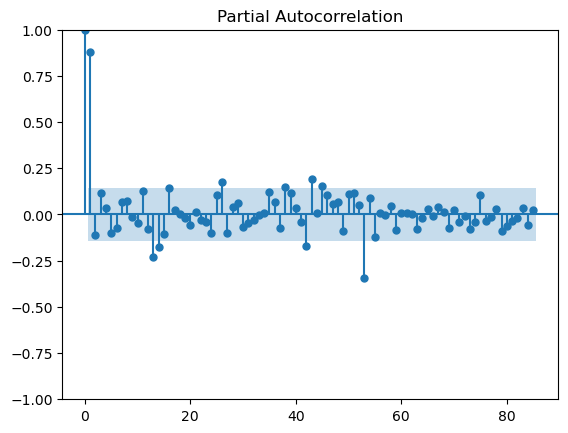

In [8]:
#ACF, PACF plots

plot_acf(data_ord_w_train['total_passenger_throughput'], lags=85)
plot_pacf(data_ord_w_train['total_passenger_throughput'], lags=85)

Expectedly there is a yearly seasonality (period = 52), and also very large pacf at 1.

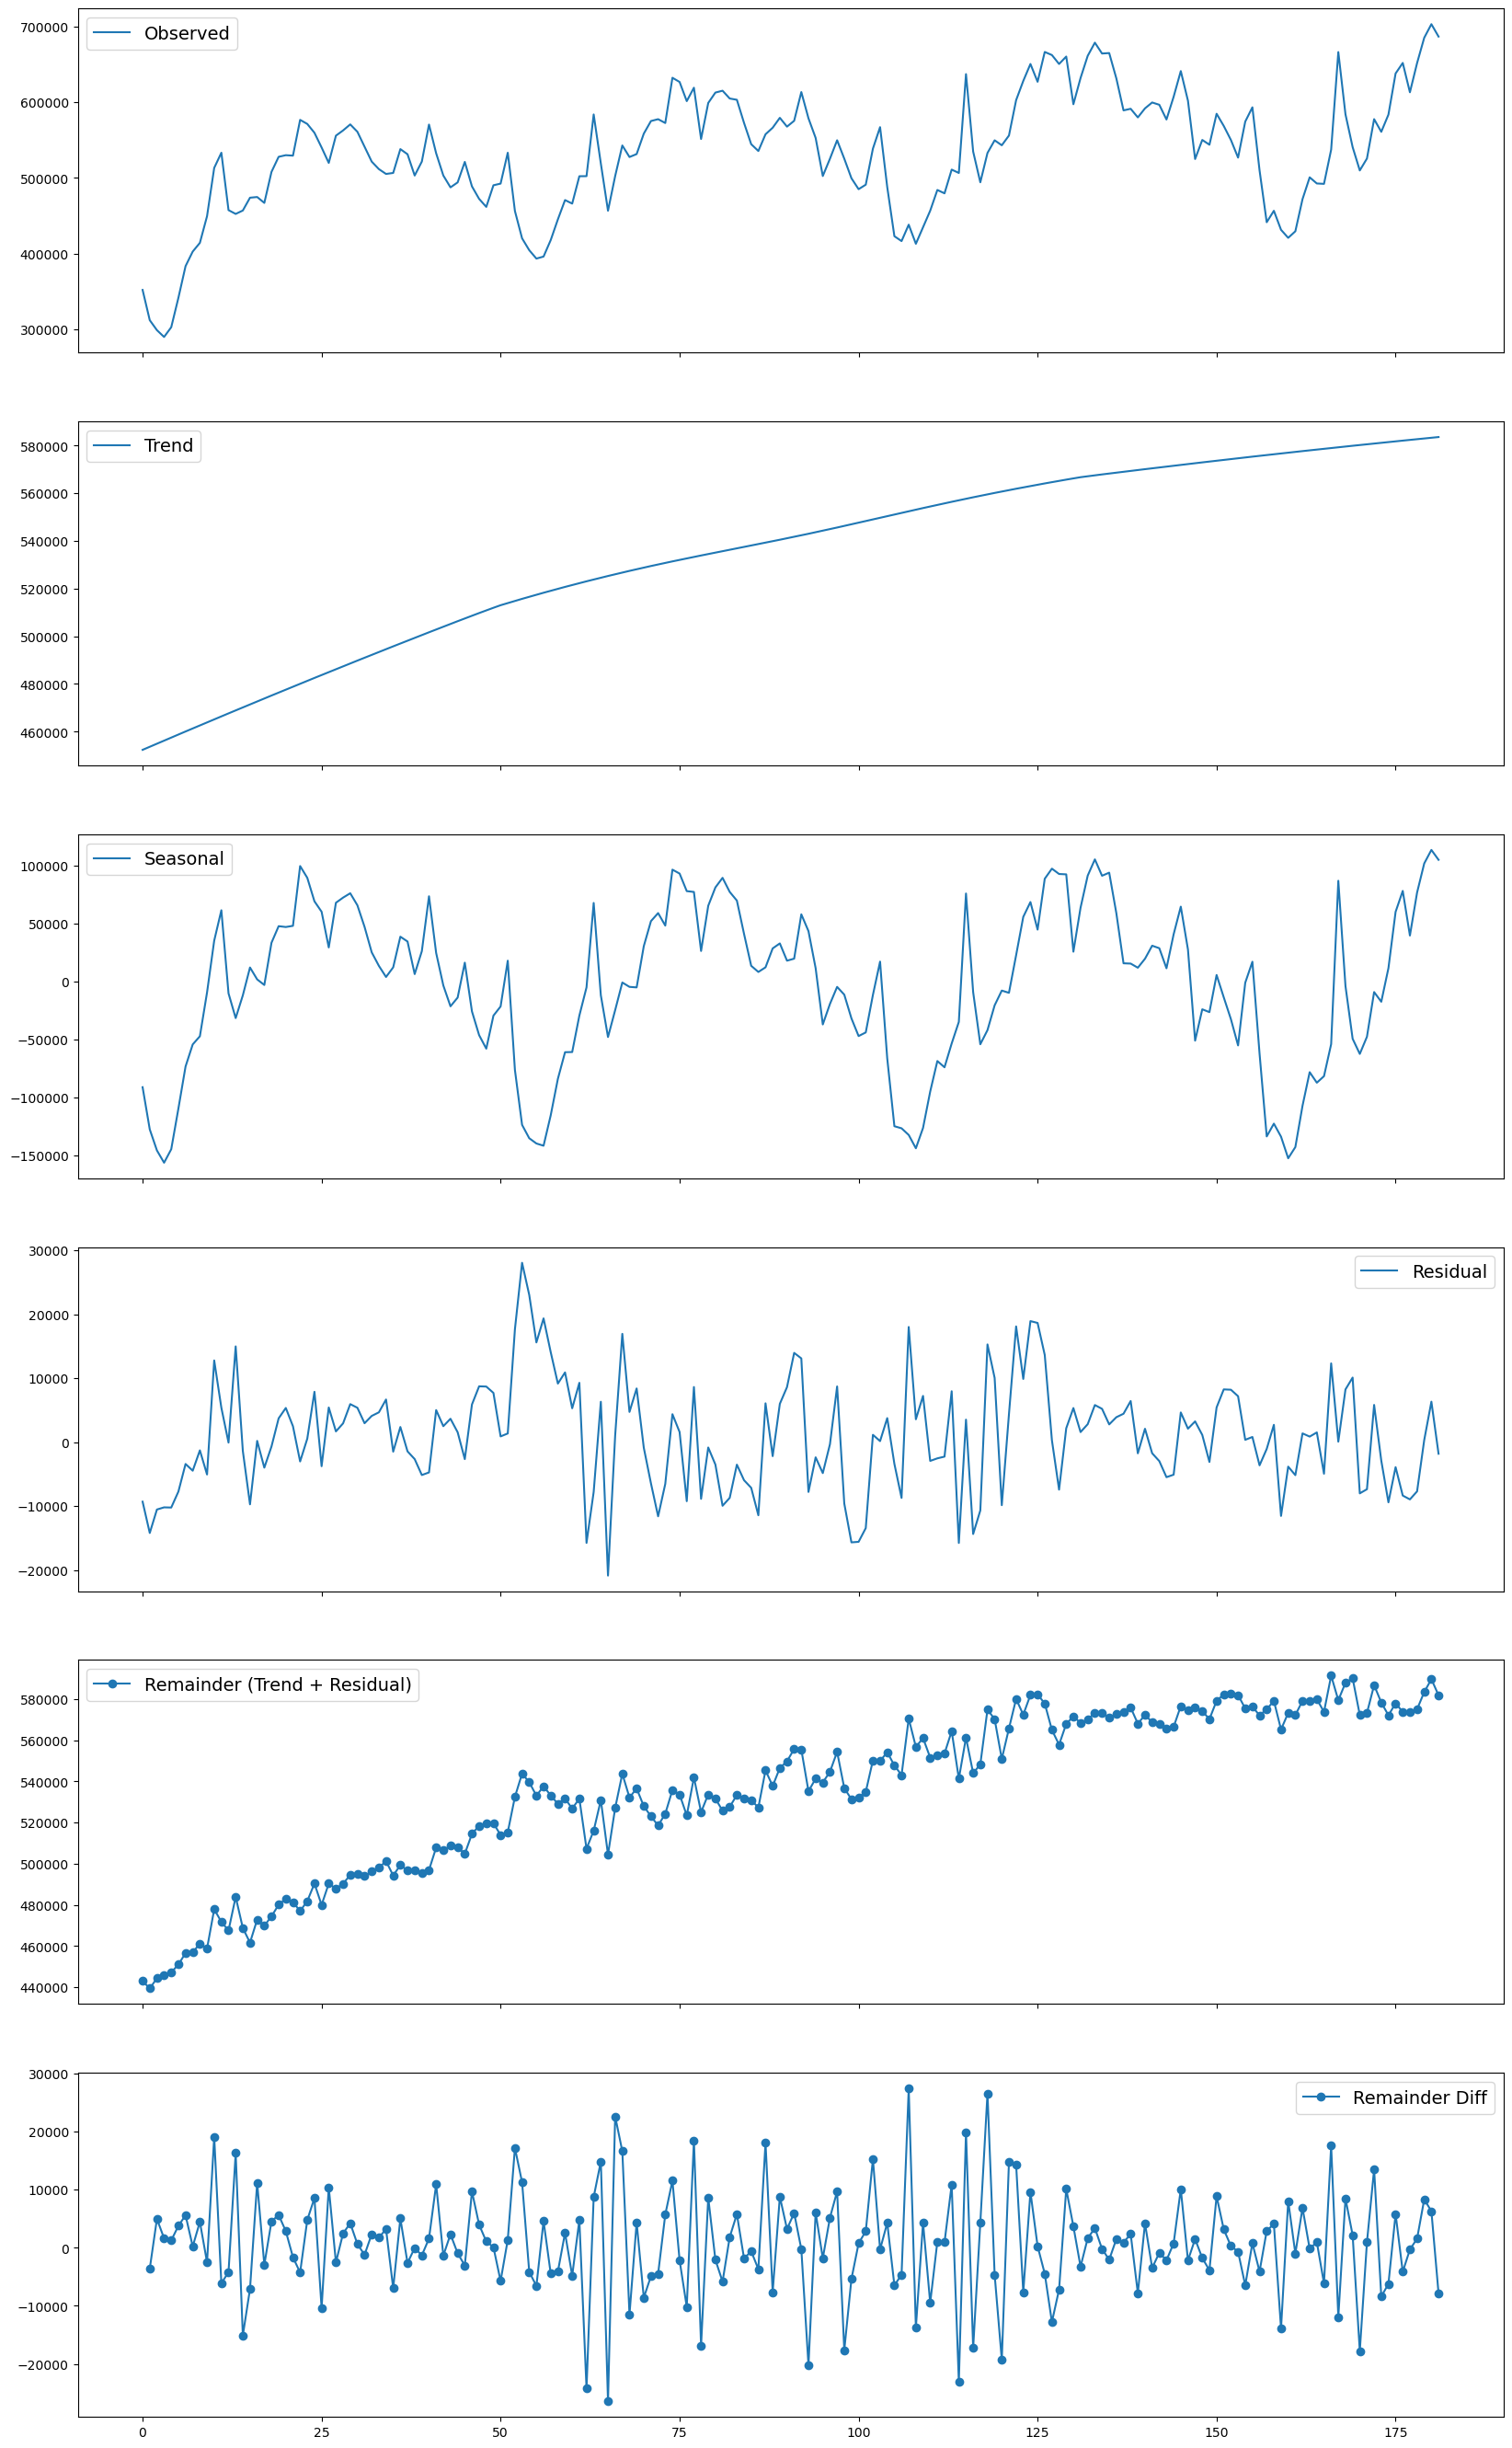

In [9]:
stl_weekly = STL(data_ord_w_train['total_passenger_throughput'], period=52)
stl_weekly_results = stl_weekly.fit()

stl_weekly_trend = stl_weekly_results.trend
stl_weekly_seasonal = stl_weekly_results.seasonal
stl_weekly_resid = stl_weekly_results.resid
stl_weekly_base = stl_weekly_results.observed

stl_weekly_trend_diff = stl_weekly_trend.diff()
stl_weekly_remainder = stl_weekly_trend + stl_weekly_resid
stl_weekly_remainder_diff = stl_weekly_remainder.diff()



fig, ax = plt.subplots(6, 1, figsize=(20, 34), sharex=True)

ax[0].plot(stl_weekly_base, label='Observed')
ax[0].legend(fontsize=14)
ax[1].plot(stl_weekly_trend, label='Trend')
ax[1].legend(fontsize=14)
ax[2].plot(stl_weekly_seasonal, label='Seasonal')
ax[2].legend(fontsize=14)
ax[3].plot(stl_weekly_resid, label='Residual')
ax[3].legend(fontsize=14)
ax[4].plot(stl_weekly_remainder, label='Remainder (Trend + Residual)', marker='o')
ax[4].legend(fontsize=14)
ax[5].plot(stl_weekly_remainder_diff, label='Remainder Diff', marker='o')
ax[5].legend(fontsize=14)

plt.show()


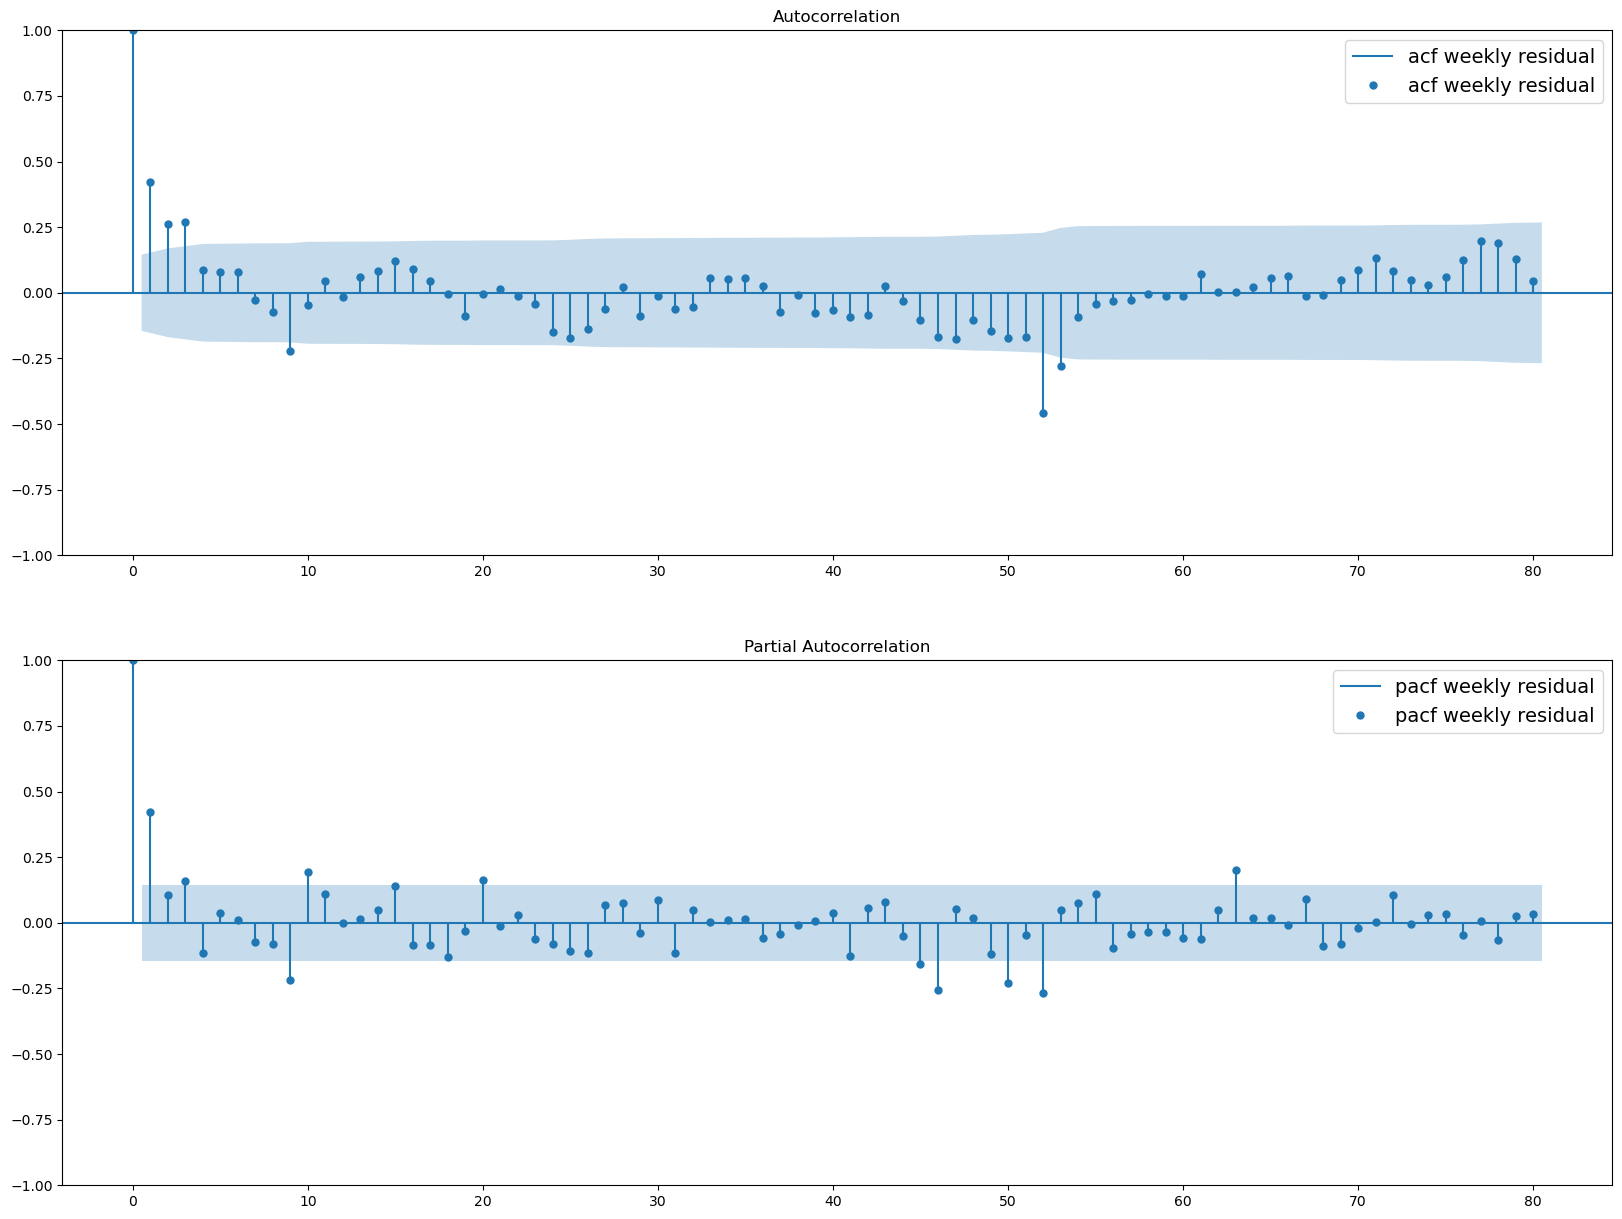

In [10]:
fig, ax = plt.subplots(2, 1, figsize=(20, 15))
plot_acf(stl_weekly_resid.dropna(), lags=80, ax=ax[0], label='acf weekly residual')
ax[0].legend(fontsize=14)
plot_pacf(stl_weekly_resid.dropna(), lags=80, ax=ax[1], label='pacf weekly residual')
ax[1].legend(fontsize=14)

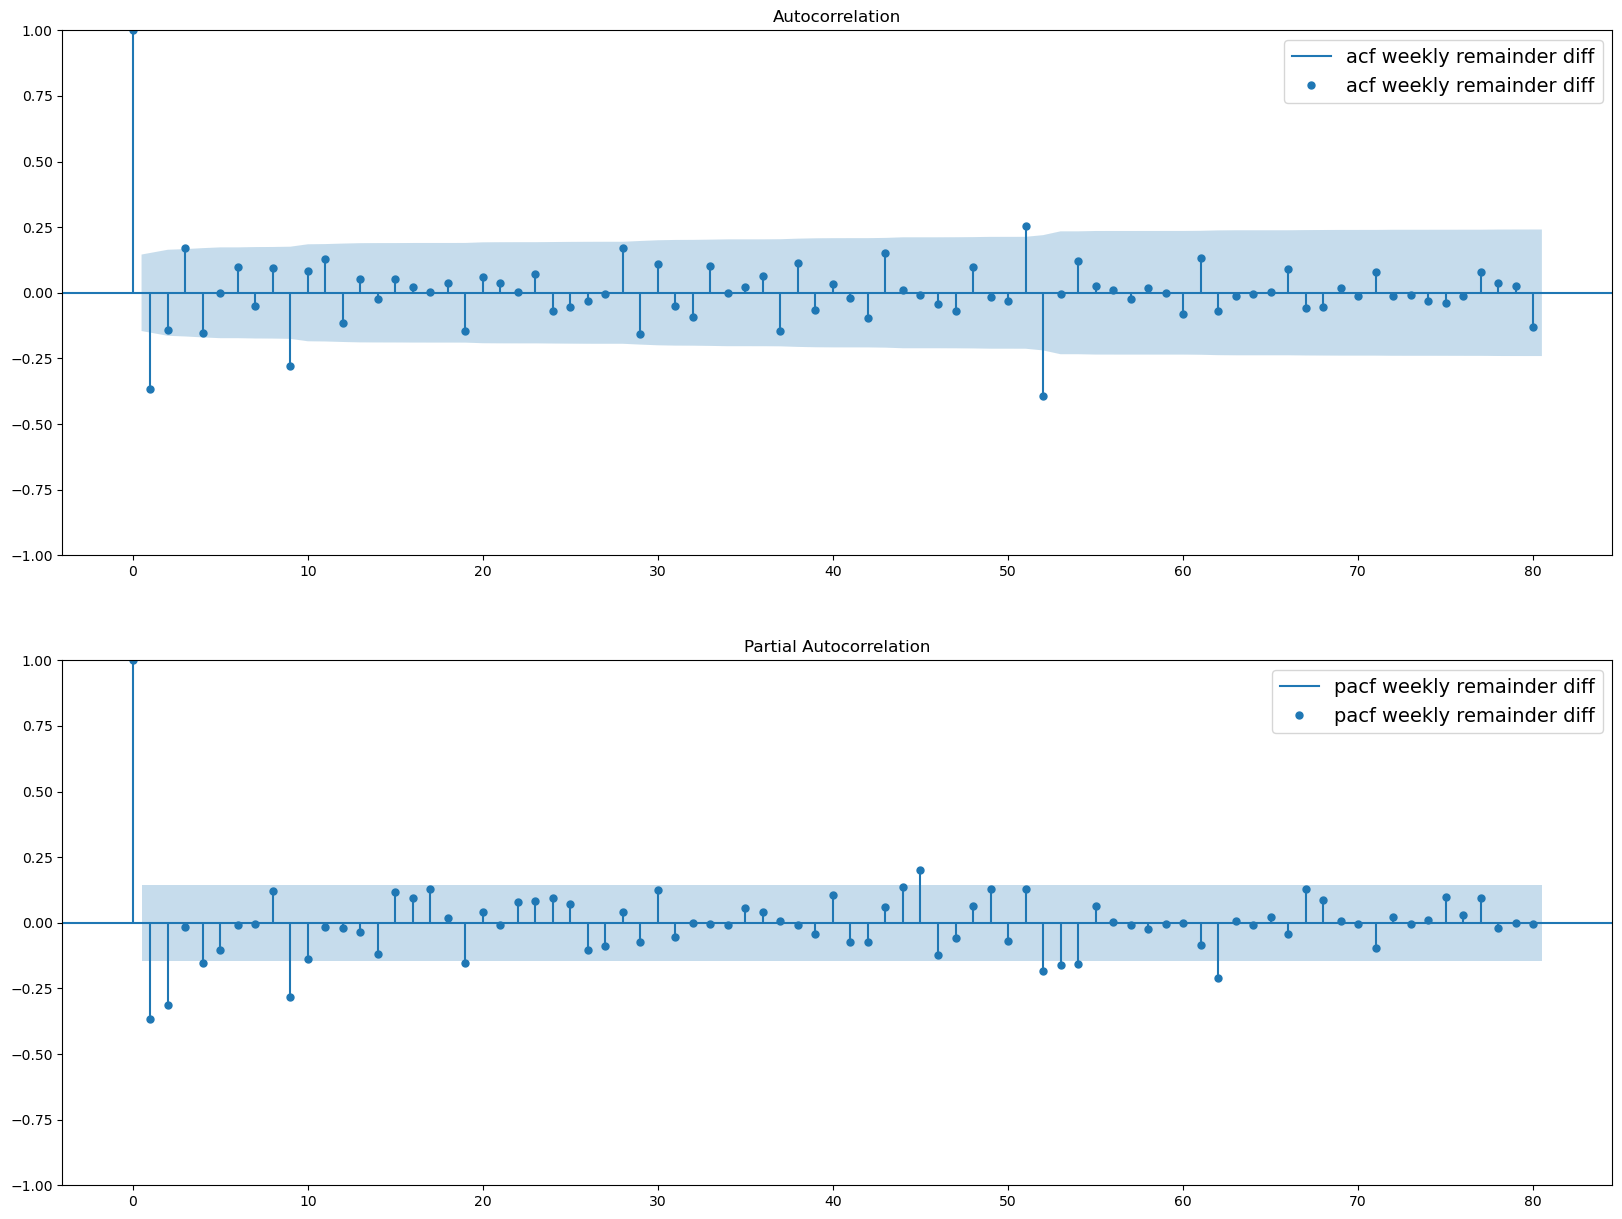

In [11]:
fig, ax = plt.subplots(2, 1, figsize=(20, 15))
plot_acf(stl_weekly_remainder_diff.dropna(), lags=80, ax=ax[0], label='acf weekly remainder diff')
ax[0].legend(fontsize=14)
plot_pacf(stl_weekly_remainder_diff.dropna(), lags=80, ax=ax[1], label='pacf weekly remainder diff')
ax[1].legend(fontsize=14)

In [12]:
#running auto-arima on the remainder (trend + residual) component of the STL decomposition. We keep m=1 for weekly seasonality.
auto_arima(stl_weekly_remainder, seasonal=True,trace = True, m=1, stepwise=True, suppress_warnings=True, error_action='ignore')

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.83 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=3812.198, Time=0.03 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=3812.501, Time=0.20 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=3814.612, Time=0.14 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=3811.519, Time=0.02 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=3816.477, Time=0.22 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 1.454 seconds


ARIMA(order=(0, 1, 0), scoring_args={}, suppress_warnings=True,
      with_intercept=False)

Let's now run STL+auto arima on the CV splits.

In [13]:
#Defining a function to run STL + SARIMA on rolling splits of the data, and evaluate the average forecasts.
def run_stl_arima_splits(df, date_col, target_col, splits, period=52):
    results = []

    for i, (train_idx, test_idx) in enumerate(splits):
        if len(test_idx) == 0:
            print(f"Split {i+1}: empty test set, skipping")
            continue

        train = df.loc[train_idx].copy()
        test  = df.loc[test_idx].copy()

        #STL decomposition
        stl     = STL(train[target_col], period=period, robust=True)
        stl_fit = stl.fit()

        seasonal = stl_fit.seasonal
        trend_resid = stl_fit.trend + stl_fit.resid  

        #SARIMA on trend + residual
        model = auto_arima(
            trend_resid,
            seasonal=True, m=1,
            stepwise=True,
            suppress_warnings=True,
            error_action='ignore',        
        )

        # Forecast
        n_forecast = len(test_idx)

        trend_resid_forecast = model.predict(n_periods=n_forecast)

        # Extend seasonal: tile last full cycle from STL
        seasonal_cycle    = seasonal.values[-period:]
        seasonal_forecast = np.tile(seasonal_cycle, int(np.ceil(n_forecast / period)))[:n_forecast]

        forecast = trend_resid_forecast + seasonal_forecast
        actuals  = test[target_col].values

        # Evaluate errors
        metrics = evaluate_forecast(actuals, forecast, model_name=f"STL-SARIMA Split {i+1}")

        results.append({
            'split':        i + 1,
            'train_size':   len(train_idx),
            'test_size':    n_forecast,
            'sarima_order': (model.order, model.seasonal_order),
            **metrics,
            'forecast':     forecast,
            'actuals':      actuals,
            'dates':        test[date_col].values,
        })

    # CV average
    if results:
        avg_mae  = np.mean([r['mae']  for r in results])
        avg_mape = np.mean([r['mape'] for r in results])
        avg_rmse = np.mean([r['rmse'] for r in results])
        print(f"\nSTL-SARIMA CV Average")
        print(f"  MAE:  {avg_mae:,.0f}")
        print(f"  MAPE: {avg_mape:.2f}%")
        print(f"  RMSE: {avg_rmse:,.0f}")

    return results

In [14]:
results= run_stl_arima_splits(data_ord_w_train, date_col='datetime', target_col='total_passenger_throughput', splits=splits, period=52)



STL-SARIMA Split 1
  MAE:  15,545
  MAPE: 2.56%
  RMSE: 19,029

STL-SARIMA Split 2
  MAE:  13,794
  MAPE: 2.19%
  RMSE: 15,848

STL-SARIMA Split 3
  MAE:  22,343
  MAPE: 3.89%
  RMSE: 26,690

STL-SARIMA Split 4
  MAE:  22,879
  MAPE: 4.91%
  RMSE: 27,775

STL-SARIMA Split 5
  MAE:  30,219
  MAPE: 5.17%
  RMSE: 36,578

STL-SARIMA CV Average
  MAE:  20,956
  MAPE: 3.74%
  RMSE: 25,184


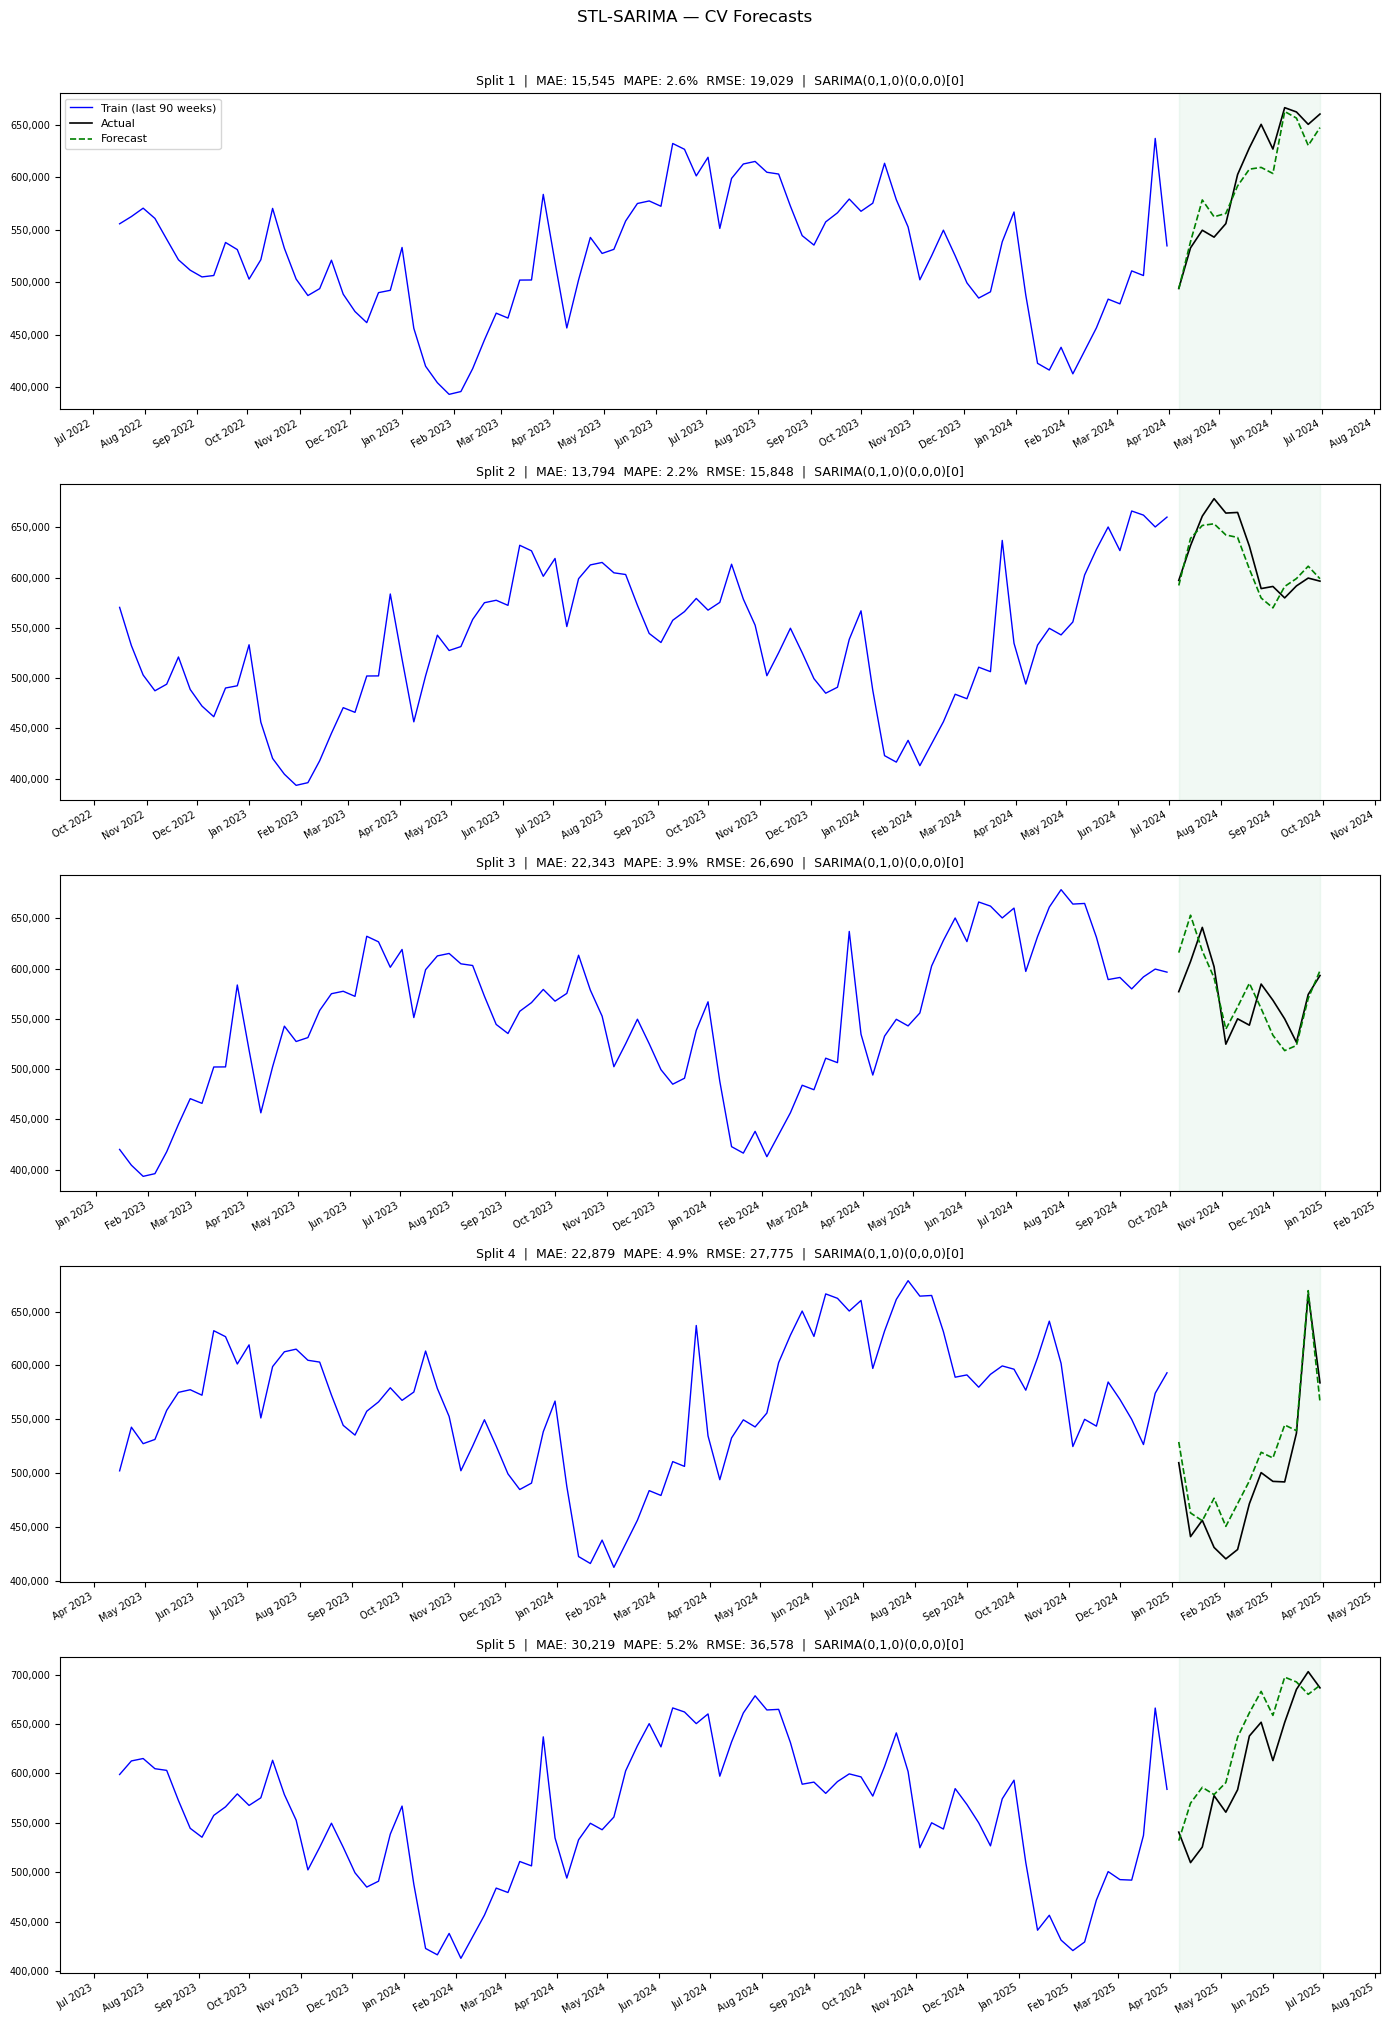

In [15]:


fig, axes = plt.subplots(len(splits), 1, figsize=(14, 20))
fig.suptitle('STL-SARIMA — CV Forecasts', y=1.01)

for i, r in enumerate(results):
    ax = axes[i]

    train_idx = splits[i][0]
    test_idx  = splits[i][1]

    train_dates = data_ord_w_train.iloc[train_idx]['datetime']
    test_dates  = data_ord_w_train.iloc[test_idx]['datetime']
    train_vals  = data_ord_w_train.iloc[train_idx]['total_passenger_throughput']

    train_plot_dates = train_dates.iloc[-90:]
    train_plot_vals  = train_vals.iloc[-90:]

    ax.plot(train_plot_dates, train_plot_vals,
            color='blue', linewidth=1, label='Train (last 90 weeks)')
    ax.plot(test_dates, r['actuals'],
            color='black', linewidth=1.2, label='Actual')
    ax.plot(test_dates, r['forecast'],
            color='green', linewidth=1.2, linestyle='--', label='Forecast')
    ax.axvspan(test_dates.iloc[0], test_dates.iloc[-1],
               alpha=0.07, color='mediumseagreen')

    p, d, q       = r['sarima_order'][0]
    P, D, Q, m    = r['sarima_order'][1]
    ax.set_title(
        f"Split {r['split']}  |  "
        f"MAE: {r['mae']:,.0f}  MAPE: {r['mape']:.1f}%  RMSE: {r['rmse']:,.0f}  |  "
        f"SARIMA({p},{d},{q})({P},{D},{Q})[{m}]",
        fontsize=9
    )

    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=7)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.tick_params(axis='y', labelsize=7)

    if i == 0:
        ax.legend(fontsize=8, loc='upper left')

plt.tight_layout()
plt.show()

Let's quickly check what we get for daily data also.

In [16]:
data_ord_d = retrieve_airport_data(data, "ORD", frequency="D")
data_ord_d.head()

,datetime,total_passenger_throughput,day
0,2022-01-02,57237,2
1,2022-01-03,61147,3
2,2022-01-04,50709,4
3,2022-01-05,46234,5
4,2022-01-06,48520,6


In [18]:

data_ord_d_train= data_ord_d[data_ord_d["datetime"] < "2025-06-24"] 
data_ord_d_train.tail()

,datetime,total_passenger_throughput,day
1264,2025-06-19,109081,170
1265,2025-06-20,97410,171
1266,2025-06-21,88671,172
1267,2025-06-22,111687,173
1268,2025-06-23,107462,174


In [24]:

splits = make_rolling_splits(data_ord_d_train, date_col='datetime', n_splits=5, step_days=90)

Split 1: train → 2024-03-30 | test 2024-03-31 → 2024-06-28 (90 days)
Split 2: train → 2024-06-28 | test 2024-06-29 → 2024-09-26 (90 days)
Split 3: train → 2024-09-26 | test 2024-09-27 → 2024-12-25 (90 days)
Split 4: train → 2024-12-25 | test 2024-12-26 → 2025-03-25 (90 days)
Split 5: train → 2025-03-25 | test 2025-03-26 → 2025-06-23 (90 days)


In [25]:
#Defining a function to run STL + SARIMA on rolling splits of the data, and evaluate the average forecasts.
def run_stl_arima_splits(df, date_col, target_col, splits, period):
    results = []

    for i, (train_idx, test_idx) in enumerate(splits):
        if len(test_idx) == 0:
            print(f"Split {i+1}: empty test set, skipping")
            continue

        train = df.loc[train_idx].copy()
        test  = df.loc[test_idx].copy()

        #STL decomposition
        stl     = STL(train[target_col], period=period, robust=True)
        stl_fit = stl.fit()

        seasonal = stl_fit.seasonal
        trend_resid = stl_fit.trend + stl_fit.resid  

        #SARIMA on trend + residual
        model = auto_arima(
            trend_resid,
            seasonal=True, m=7,
            stepwise=True,
            suppress_warnings=True,
            error_action='ignore',        
        )

        # Forecast
        n_forecast = len(test_idx)

        trend_resid_forecast = model.predict(n_periods=n_forecast)

        # Extend seasonal: tile last full cycle from STL
        seasonal_cycle    = seasonal.values[-period:]
        seasonal_forecast = np.tile(seasonal_cycle, int(np.ceil(n_forecast / period)))[:n_forecast]

        forecast = trend_resid_forecast + seasonal_forecast
        actuals  = test[target_col].values

        # Evaluate errors
        metrics = evaluate_forecast(actuals, forecast, model_name=f"STL-SARIMA Split {i+1}")

        results.append({
            'split':        i + 1,
            'train_size':   len(train_idx),
            'test_size':    n_forecast,
            'sarima_order': (model.order, model.seasonal_order),
            **metrics,
            'forecast':     forecast,
            'actuals':      actuals,
            'dates':        test[date_col].values,
        })

    # CV average
    if results:
        avg_mae  = np.mean([r['mae']  for r in results])
        avg_mape = np.mean([r['mape'] for r in results])
        avg_rmse = np.mean([r['rmse'] for r in results])
        print(f"\nSTL-SARIMA CV Average")
        print(f"  MAE:  {avg_mae:,.0f}")
        print(f"  MAPE: {avg_mape:.2f}%")
        print(f"  RMSE: {avg_rmse:,.0f}")

    return results

In [26]:
results= run_stl_arima_splits(data_ord_d_train, date_col='datetime', target_col='total_passenger_throughput', splits=splits, period=365)


STL-SARIMA Split 1
  MAE:  8,512
  MAPE: 10.31%
  RMSE: 10,175

STL-SARIMA Split 2
  MAE:  9,216
  MAPE: 10.77%
  RMSE: 11,437

STL-SARIMA Split 3
  MAE:  10,363
  MAPE: 13.35%
  RMSE: 13,363

STL-SARIMA Split 4
  MAE:  7,949
  MAPE: 11.84%
  RMSE: 9,889

STL-SARIMA Split 5
  MAE:  9,776
  MAPE: 12.00%
  RMSE: 12,177

STL-SARIMA CV Average
  MAE:  9,163
  MAPE: 11.65%
  RMSE: 11,408
